In [1]:
from google.colab import drive
#drive.flush_and_unmount()
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
%cd gdrive/MyDrive/ROBUST_TIME SERIES_CLASSIFICATION/AnomalyBERT-main

/content/gdrive/MyDrive/ROBUST_TIME SERIES_CLASSIFICATION/AnomalyBERT-main


In [3]:
# =========================================================
# End-to-end: synthetic (Appendix E/E.1) + window classifier
# - Train-normal z-score normalization (no leakage)
# - Robust DataLoader (workers=0 by default)
# - torch.amp (no deprecations)
# - Per-epoch threshold grid search on synthetic-val (as before)
# =========================================================
import os, math, gc, json, random, warnings
from typing import Tuple, List, Dict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, precision_recall_fscore_support, accuracy_score,
    precision_score, recall_score, f1_score
)

# ---------- Notebook/Colab-safe multiprocessing ----------
import torch.multiprocessing as mp
try:
    mp.set_start_method("spawn", force=True)
except RuntimeError:
    pass
try:
    torch.multiprocessing.set_sharing_strategy("file_system")
except RuntimeError:
    pass

torch.set_float32_matmul_precision("high")

In [29]:


# -------------------------
# Config
# -------------------------
USE_SYNTHETIC = True        # <-- True: use Appendix E/E.1 generator; False: load CSV
CSV_PATH = "/content/your_dataset.csv"   # used only when USE_SYNTHETIC=False
LABEL_COL = "Label"
MAX_ROWS = 1_000_000

# Chronological split
VAL_FRACTION  = 0.20
TEST_FRACTION = 0.20

# Windows
WINDOW       = 100
TRAIN_STRIDE = 20
VAL_STRIDE   = 20
TEST_STRIDE  = 20

# Synthetic patching (train + val)
DEGRADE_MIN = 0.25
DEGRADE_MAX = 0.75
ANOMALY_BANK_MAX = 6000
VAL_POS_FRAC = 0.25      # synthetic-val positives fraction (same as before)

# Training
EPOCHS       = 25
BATCH_SIZE   = 128
LR           = 3e-4
WEIGHT_DECAY = 1e-4
CLIP_NORM    = 1.0

DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_TYPE  = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP      = torch.cuda.is_available()
PIN_MEMORY   = torch.cuda.is_available()

# DataLoader (safe defaults in notebooks)
NUM_WORKERS = 0
PERSIST     = False

EVAL_BATCH  = 1024

# Model
MODEL_KIND = "bert"     # "plain" | "bert"
D_MODEL = 128
NHEAD   = 4
NLAYERS = 2
FF_MULT = 4
PDROP   = 0.2
PATCH_SIZE = 10          # WINDOW ideally multiple; we crop to multiple internally

# Repro
SEED = 1337
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

In [30]:


# -------------------------
# Utility funcs (windows, labels, etc.)
# -------------------------
def sliding_windows(x: np.ndarray, y: np.ndarray, win: int, stride: int):
    L = len(x)
    xs, ys = [], []
    for s in range(0, L - win + 1, stride):
        xs.append(x[s:s+win])
        ys.append(y[s:s+win])
    if not xs:
        return (np.zeros((0, win, x.shape[1]), dtype=np.float32),
                np.zeros((0, win), dtype=np.int32))
    return np.stack(xs).astype(np.float32), np.stack(ys).astype(np.int32)

def window_label_from_series(ywin: np.ndarray) -> np.ndarray:
    return (ywin.sum(axis=1) > 0).astype(np.int32)

def extract_anomaly_spans(y: np.ndarray) -> List[Tuple[int,int]]:
    spans, i, L = [], 0, len(y)
    while i < L:
        if y[i] == 1:
            j = i
            while j + 1 < L and y[j+1] == 1: j += 1
            spans.append((i, j+1))
            i = j + 1
        else:
            i += 1
    return spans

def resample_len(x: np.ndarray, out_len: int) -> np.ndarray:
    T, D = x.shape
    if T == out_len: return x.copy()
    old = np.linspace(0.0, 1.0, T, dtype=np.float32)
    new = np.linspace(0.0, 1.0, out_len, dtype=np.float32)
    y = np.empty((out_len, D), dtype=np.float32)
    for d in range(D):
        y[:, d] = np.interp(new, old, x[:, d])
    return y

def aug_light(x: np.ndarray) -> np.ndarray:
    T, D = x.shape
    s = np.random.uniform(0.95, 1.05, size=(1, D)).astype(np.float32)
    y = x * s
    y = y + np.random.normal(0, 0.01, size=y.shape).astype(np.float32)
    end = np.random.uniform(-0.05, 0.05, size=(1, D)).astype(np.float32)
    trend = np.linspace(0, 1, T, dtype=np.float32).reshape(T,1) * end
    return y + trend

def safe_auc(ytrue: np.ndarray, yscore: np.ndarray) -> float:
    try:
        if len(np.unique(ytrue)) < 2: return float('nan')
        return roc_auc_score(ytrue, yscore)
    except Exception:
        return float('nan')

In [31]:


# -------------------------
# Normalization
# -------------------------
def fit_zscore(X: np.ndarray):
    mu = X.mean(axis=0, keepdims=True).astype(np.float32)
    sd = X.std(axis=0, keepdims=True).astype(np.float32)
    sd[sd < 1e-8] = 1e-8
    return mu, sd

def apply_zscore(X: np.ndarray, mu: np.ndarray, sd: np.ndarray):
    return ((X - mu) / sd).astype(np.float32)

# =========================================================
# Synthetic generator (Appendix E / E.1)
# =========================================================
SYNTH_CONF = {
    "T": 120_000, "D": 32, "n_events": 40,
    "event_len_min": 200, "event_len_max": 800,
    "dependency_strength": 0.45,     # α (B_norm scale / spectral radius)
    "anomaly_dependency_shift": 0.30,# δ (added to B_norm then re-stabilized)
    "marginals": {
        "affine": {"smin": 0.9, "smax": 1.1, "bmin": -0.15, "bmax": 0.15},
        "K": 2,
        "power_pmin": 0.75, "power_pmax": 1.4,
        "logsoft_amin": 0.8, "logsoft_amax": 1.6,
        "sinh_bmin": 0.25, "sinh_bmax": 0.5,
        "noise_sigma": 0.05,
        "noise_sinus_amp": 0.6
    },
    "noise_base_sigma": 0.02,
    "seed": 1337
}

def preset_case(case: int):
    if case == 1:
        return {
            "dependency_strength": 0.35,
            "anomaly_dependency_shift": 0.36,
            "marginals": {
                "affine": {"smin": 0.95, "smax": 1.05, "bmin": -0.08, "bmax": 0.08},
                "K": 1, "power_pmin": 0.85, "power_pmax": 1.2,
                "logsoft_amin": 0.5, "logsoft_amax": 1.0,
                "sinh_bmin": 0.15, "sinh_bmax": 0.3,
                "noise_sigma": 0.03, "noise_sinus_amp": 0.3
            }
        }
    if case == 2:
        return {
            "dependency_strength": 0.35,
            "anomaly_dependency_shift": 0.70,
            "marginals": {
                "affine": {"smin": 0.75, "smax": 1.35, "bmin": -0.35, "bmax": 0.35},
                "K": 3, "power_pmin": 0.6, "power_pmax": 1.6,
                "logsoft_amin": 1.5, "logsoft_amax": 3.0,
                "sinh_bmin": 0.4, "sinh_bmax": 0.8,
                "noise_sigma": 0.08, "noise_sinus_amp": 1.0
            }
        }
    # Case 3: strong joint shift + near-identity marginals
    return {
        "dependency_strength": 0.35,
        "anomaly_dependency_shift": 0.70,
        "marginals": {
            "affine": {"smin": 0.995, "smax": 1.005, "bmin": -0.005, "bmax": 0.005},
            "K": 0,
            "power_pmin": 1.0, "power_pmax": 1.0,
            "logsoft_amin": 0.0, "logsoft_amax": 0.0,
            "sinh_bmin": 0.0, "sinh_bmax": 0.0,
            "noise_sigma": 0.0, "noise_sinus_amp": 0.0
        }
    }

def _spectral_norm(M):
    v = np.random.randn(M.shape[1], 1).astype(np.float32)
    for _ in range(3):
        v = M.T @ (M @ v)
        v /= (np.linalg.norm(v) + 1e-9)
    s = float(np.linalg.norm(M @ v))
    return max(s, 1e-9)

def _make_stable_matrix(D, strength, rng):
    A = rng.normal(0, 1.0, size=(D, D)).astype(np.float32)
    A *= 0.25
    for i in range(D):
        A[i, i] += rng.uniform(0.3, 0.7)
        if i+1 < D: A[i, i+1] += rng.uniform(0.1, 0.3)
        if i-1 >= 0: A[i, i-1] += rng.uniform(0.1, 0.3)
    s = _spectral_norm(A)
    B = (A / s) * strength
    return B.astype(np.float32)

def _shift_dependency(Bnorm, delta, rng):
    D = Bnorm.shape[0]
    R = rng.normal(0, 1.0, size=(D, D)).astype(np.float32)
    u = rng.normal(0, 1.0, size=(D, 4)).astype(np.float32)
    v = rng.normal(0, 1.0, size=(4, D)).astype(np.float32)
    Delta = (R * 0.15 + (u @ v) * 0.2).astype(np.float32)
    s = _spectral_norm(Delta)
    Banom = Bnorm + (Delta / s) * delta
    sB = _spectral_norm(Banom)
    if sB >= 0.98:
        Banom = Banom * (0.98 / sB)
    return Banom.astype(np.float32)

def _apply_marginal_warps(Xseg, t0, t1, params, T_total):
    if params is None: return
    D = Xseg.shape[1]
    smin, smax = params["affine"]["smin"], params["affine"]["smax"]
    bmin, bmax = params["affine"]["bmin"], params["affine"]["bmax"]
    s = np.random.uniform(smin, smax, size=(1, D)).astype(np.float32)
    b = np.random.uniform(bmin, bmax, size=(1, D)).astype(np.float32)
    Xseg[:] = Xseg * s + b
    K = params["K"]
    for _ in range(K):
        k = np.random.choice(["power", "logsoft", "sinh"])
        if k == "power":
            p = np.random.uniform(params["power_pmin"], params["power_pmax"])
            Xseg[:] = np.sign(Xseg) * (np.abs(Xseg) ** p)
        elif k == "logsoft":
            a = np.random.uniform(params["logsoft_amin"], params["logsoft_amax"])
            Xseg[:] = np.sign(Xseg) * np.log1p(a * np.abs(Xseg))
        elif k == "sinh":
            bsh = np.random.uniform(params["sinh_bmin"], params["sinh_bmax"])
            Xseg[:] = np.sinh(bsh * Xseg)
    sigma0 = params["noise_sigma"]
    A = params["noise_sinus_amp"]
    if sigma0 > 0.0:
        t = np.arange(t0, t1, dtype=np.float32).reshape(-1, 1)
        sigma_t = sigma0 * (1.0 + A * np.sin(2.0 * np.pi * t / float(T_total)))
        noise = np.random.normal(0.0, 1.0, size=Xseg.shape).astype(np.float32) * np.clip(sigma_t, 0.0, None)
        Xseg[:] = Xseg + noise

def make_synth_dataset_E_cases(
    T=120_000, D=32, n_events=30, event_len_min=200, event_len_max=800,
    dependency_strength=0.45, anomaly_dependency_shift=0.30,
    marginals=None, noise_base_sigma=0.02, seed=1337
):
    rng = np.random.default_rng(seed)
    Bnorm = _make_stable_matrix(D, dependency_strength, rng)
    Banom = _shift_dependency(Bnorm, anomaly_dependency_shift, rng)
    spans = []
    t = 0
    while len(spans) < n_events and t < T - event_len_min:
        gap = rng.integers(event_len_min, event_len_min * 3)
        t = int(t + gap)
        L = int(rng.integers(event_len_min, event_len_max + 1))
        if t + L >= T: break
        spans.append((t, t + L))
        t += L
    X = np.zeros((T, D), dtype=np.float32)
    X[0] = rng.normal(0, 0.2, size=(D,)).astype(np.float32)
    eps = rng.normal(0, noise_base_sigma, size=(T, D)).astype(np.float32)
    is_anom = np.zeros((T,), dtype=np.int32)
    for a, b in spans: is_anom[a:b] = 1
    for tt in range(1, T):
        B = Banom if is_anom[tt] == 1 else Bnorm
        X[tt] = (X[tt-1] @ B.T) + eps[tt]
    if marginals is not None:
        for a, b in spans:
            _apply_marginal_warps(X[a:b], a, b, marginals, T)
    df = pd.DataFrame(X, columns=[f"f{i}" for i in range(D)])
    df["Label"] = is_anom.astype(np.int32)
    return df, spans, Bnorm, Banom

In [32]:
# --- Generate synthetic (or load CSV) ---
if USE_SYNTHETIC:
    # Example: to use a preset, uncomment one:
    #SYNTH_CONF.update(preset_case(1))
    SYNTH_CONF.update(preset_case(2))
    # SYNTH_CONF.update(preset_case(3))
    print("[synthetic] Generating dataset per Appendix E / E.1 …")
    df = None
    df, spans, Bnorm, Banom = make_synth_dataset_E_cases(
        T=SYNTH_CONF["T"], D=SYNTH_CONF["D"],
        n_events=SYNTH_CONF["n_events"],
        event_len_min=SYNTH_CONF["event_len_min"],
        event_len_max=SYNTH_CONF["event_len_max"],
        dependency_strength=SYNTH_CONF["dependency_strength"],
        anomaly_dependency_shift=SYNTH_CONF["anomaly_dependency_shift"],
        marginals=SYNTH_CONF["marginals"],
        noise_base_sigma=SYNTH_CONF["noise_base_sigma"],
        seed=SYNTH_CONF["seed"]
    )
    print(f"[synthetic] T={len(df)} D={SYNTH_CONF['D']} events={len(spans)}")
else:
    df = pd.read_csv(CSV_PATH).iloc[:MAX_ROWS].dropna()

# -------------------------
# Chronological split
# -------------------------
X_all = df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y_all = df[LABEL_COL].values.astype(np.int32)
N = len(df)

n_test = int(N * TEST_FRACTION)
n_val  = int(N * VAL_FRACTION)
n_train = N - n_val - n_test
assert n_train > WINDOW, "Training split too small for given WINDOW."

X_train_raw, y_train_raw = X_all[:n_train],               y_all[:n_train]
X_val_raw,   y_val_raw   = X_all[n_train:n_train+n_val],  y_all[n_train:n_train+n_val]
X_test_raw,  y_test_raw  = X_all[n_train+n_val:],         y_all[n_train+n_val:]

# -------------------------
# Normalization — fit on TRAIN NORMALS only
# -------------------------
train_norm_mask = (y_train_raw == 0)
assert train_norm_mask.any(), "Need some train normals to fit normalization."
mu_norm, sd_norm = fit_zscore(X_train_raw[train_norm_mask])

X_train = apply_zscore(X_train_raw, mu_norm, sd_norm)
X_val   = apply_zscore(X_val_raw,   mu_norm, sd_norm)
X_test  = apply_zscore(X_test_raw,  mu_norm, sd_norm)

print("[norm] z-score fitted on TRAIN NORMALS and applied.")

# -------------------------
# Build anomaly bank (from TRAIN anomalies) for patching
# -------------------------
def build_anomaly_bank_from_train() -> List[np.ndarray]:
    spans = extract_anomaly_spans(y_train_raw)
    if len(spans) == 0:
        # fallback: borrow from val anomalies so training works
        spans = extract_anomaly_spans(y_val_raw)
    rng = np.random.default_rng(SEED); rng.shuffle(spans)
    spans = spans[:ANOMALY_BANK_MAX]
    bank = []
    for a,b in spans:
        seg = X_train_raw[a:b].astype(np.float32) if b <= len(X_train_raw) else X_val_raw[a - len(X_train_raw):b - len(X_train_raw)]
        bank.append(apply_zscore(seg, mu_norm, sd_norm))
    return bank

bank = build_anomaly_bank_from_train()
if len(bank) == 0:
    raise RuntimeError("No anomaly spans in TRAIN/VAL to build patch bank.")

# -------------------------
# TRAIN windows: normals -> degraded copy
# -------------------------
Xw_tr, Yw_tr = sliding_windows(X_train, y_train_raw, WINDOW, TRAIN_STRIDE)
mask_normal_win = (Yw_tr.sum(axis=1) == 0)
Xw_tr = Xw_tr[mask_normal_win]

Ntr = len(Xw_tr)
Xw_deg = np.empty_like(Xw_tr, dtype=np.float32)

for i in range(Ntr):
    x = Xw_tr[i].copy()
    frac = np.random.uniform(DEGRADE_MIN, DEGRADE_MAX)
    Ld   = max(4, int(round(frac * WINDOW)))
    s = np.random.randint(0, WINDOW - Ld + 1); e = s + Ld
    patch = bank[np.random.randint(0, len(bank))]
    patch = resample_len(patch, Ld)
    patch = aug_light(patch)
    mu_x  = x[s:e].mean(axis=0, keepdims=True)
    sd_x  = x[s:e].std(axis=0, keepdims=True) + 1e-6
    mu_p  = patch.mean(axis=0, keepdims=True)
    sd_p  = patch.std(axis=0, keepdims=True) + 1e-6
    patch = (patch - mu_p) / sd_p * sd_x + mu_x
    x[s:e] = patch
    Xw_deg[i] = x

X_train_cls = np.concatenate([Xw_tr, Xw_deg], axis=0)
y_train_cls = np.concatenate([np.zeros(Ntr, np.int32), np.ones(Ntr, np.int32)], axis=0)
perm = np.random.default_rng(SEED).permutation(len(X_train_cls))
X_train_cls, y_train_cls = X_train_cls[perm], y_train_cls[perm]

[synthetic] Generating dataset per Appendix E / E.1 …
[synthetic] T=120000 D=32 events=40
[norm] z-score fitted on TRAIN NORMALS and applied.


In [33]:



# -------------------------
# VAL (synthetic, deterministic): patch subset of val-normal windows
# -------------------------
Xv_all, Yv_all = sliding_windows(X_val, y_val_raw, WINDOW, VAL_STRIDE)
v_norm_mask = (Yv_all.sum(axis=1) == 0)
Xv_norm = Xv_all[v_norm_mask]

Nv = len(Xv_norm)
Nv_pos = int(round(VAL_POS_FRAC * Nv))
rng = np.random.default_rng(12345)  # fixed seed => deterministic val
idx_perm = rng.permutation(Nv)
idx_pos, idx_neg = idx_perm[:Nv_pos], idx_perm[Nv_pos:]

Xv_pos = np.empty((Nv_pos, WINDOW, Xv_norm.shape[2]), dtype=np.float32)
for k, i in enumerate(idx_pos):
    x = Xv_norm[i].copy()
    frac = rng.uniform(DEGRADE_MIN, DEGRADE_MAX)
    Ld   = max(4, int(round(frac * WINDOW)))
    s = rng.integers(0, WINDOW - Ld + 1); e = s + Ld
    patch = bank[rng.integers(0, len(bank))]
    patch = resample_len(patch, Ld)
    patch = aug_light(patch)
    mu_x  = x[s:e].mean(axis=0, keepdims=True)
    sd_x  = x[s:e].std(axis=0, keepdims=True) + 1e-6
    mu_p  = patch.mean(axis=0, keepdims=True)
    sd_p  = patch.std(axis=0, keepdims=True) + 1e-6
    patch = (patch - mu_p) / sd_p * sd_x + mu_x
    x[s:e] = patch
    Xv_pos[k] = x

Xv_neg = Xv_norm[idx_neg]
Xv_syn = np.concatenate([Xv_neg, Xv_pos], axis=0)
yv_syn = np.concatenate([np.zeros(len(Xv_neg), np.int32), np.ones(len(Xv_pos), np.int32)], axis=0)

# -------------------------
# TEST windows (real labels → window label)
# -------------------------
Xt_win, Yt_win = sliding_windows(X_test, y_test_raw, WINDOW, TEST_STRIDE)
yt_lbl = window_label_from_series(Yt_win)

print(f"TRAIN windows: {len(X_train_cls)} (balanced)")
print(f"VAL (synthetic, deterministic): {len(Xv_syn)}  pos={int(yv_syn.sum())} ({100*yv_syn.mean():.1f}%)")
print(f"TEST windows: {len(Xt_win)}  pos(real)={int(yt_lbl.sum())} ({100*yt_lbl.mean():.1f}%)")

# -------------------------
# Preflight checks
# -------------------------
def check_array(name, X):
    assert isinstance(X, np.ndarray), f"{name} not ndarray"
    assert X.dtype == np.float32, f"{name} dtype {X.dtype}"
    assert X.ndim == 3, f"{name} ndim {X.ndim}"
    assert X.shape[1] == WINDOW, f"{name} window len {X.shape[1]} != {WINDOW}"
    assert np.all(np.isfinite(X)), f"NaN/Inf in {name}"

def check_labels(name, y):
    assert isinstance(y, np.ndarray), f"{name} not ndarray"
    assert y.ndim == 1, f"{name} ndim {y.ndim}"
    assert y.dtype in (np.int32, np.int64), f"{name} dtype {y.dtype}"

check_array("X_train_cls", X_train_cls); check_labels("y_train_cls", y_train_cls)
check_array("Xv_syn", Xv_syn);           check_labels("yv_syn", yv_syn)
check_array("Xt_win", Xt_win);           check_labels("yt_lbl", yt_lbl.astype(np.int32))

TRAIN windows: 4774 (balanced)
VAL (synthetic, deterministic): 1196  pos=299 (25.0%)
TEST windows: 1196  pos(real)=0 (0.0%)


In [34]:



# -------------------------
# Dataset / Dataloader
# -------------------------
class WinClsDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i], dtype=torch.float32)

def collate_safe(batch):
    xs, ys = zip(*batch)
    xs = [x.contiguous() for x in xs]
    return torch.stack(xs, 0), torch.stack(ys, 0)

train_ds = WinClsDataset(X_train_cls, y_train_cls)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=PERSIST,
    collate_fn=collate_safe
)


In [35]:

# -------------------------
# Models
# -------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 10000):
        super().__init__()
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe, persistent=False)
    def forward(self, x):  # [B,T,D]
        T = x.size(1)
        return x + self.pe[:T]

def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    B, T, D = x.shape
    Lp = (T // patch_size) * patch_size
    x = x[:, :Lp, :]
    return x.reshape(B, Lp // patch_size, patch_size * D)

class TransformerWindowClassifier(nn.Module):
    def __init__(self, d_in: int, d_model: int, nhead: int, nlayers: int, ff_mult: int, pdrop: float, patch_size: int):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Linear(d_in * patch_size, d_model)
        enc = nn.TransformerEncoderLayer(d_model, nhead, ff_mult*d_model, dropout=pdrop,
                                         batch_first=True, activation='gelu')
        self.enc = nn.TransformerEncoder(enc, num_layers=nlayers)
        self.pos = PositionalEncoding(d_model)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)
        nn.init.xavier_uniform_(self.proj.weight); nn.init.zeros_(self.proj.bias)
        nn.init.xavier_uniform_(self.head.weight); nn.init.zeros_(self.head.bias)
    def forward(self, x):  # x: [B,T,D]
        x = patchify(x, self.patch_size)
        h = self.proj(x)
        h = self.pos(h)
        h = self.enc(h)
        h = self.norm(h.mean(dim=1))
        return self.head(h).squeeze(-1)  # logits (B,)

class AnomalyBertWindowClassifier(nn.Module):
    def __init__(self, input_dim: int, model_dim: int = 128, num_heads: int = 4, num_layers: int = 2,
                 dropout: float = 0.2, max_len: int = 2048):
        super().__init__()
        self.model_dim = model_dim
        self.input_proj = nn.Linear(input_dim, model_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, model_dim))
        self.pos_embed = nn.Embedding(max_len + 1, model_dim)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads, dim_feedforward=model_dim*4,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(model_dim)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(model_dim, 1)
        nn.init.trunc_normal_(self.pos_embed.weight, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)
    def forward(self, x):
        B, L, _ = x.shape
        z = self.input_proj(x)
        cls = self.cls_token.expand(B, 1, self.model_dim)
        z = torch.cat([cls, z], dim=1)
        pos_ids = torch.arange(L + 1, device=x.device).unsqueeze(0)
        z = self.drop(z + self.pos_embed(pos_ids))
        z = self.encoder(z)
        cls_out = self.norm(z[:, 0, :])
        return self.head(cls_out).squeeze(1)  # logits (B,)

D_in = X_train_cls.shape[2]
if MODEL_KIND == "plain":
    model = TransformerWindowClassifier(D_in, D_MODEL, NHEAD, NLAYERS, FF_MULT, PDROP, PATCH_SIZE).to(DEVICE)
else:
    model = AnomalyBertWindowClassifier(D_in, D_MODEL, NHEAD, NLAYERS, PDROP, max_len=WINDOW).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler(DEVICE_TYPE, enabled=USE_AMP)

In [36]:


# -------------------------
# Inference & thresholding helpers
# -------------------------
@torch.no_grad()
def infer_window_scores(model: nn.Module, Xw: np.ndarray) -> np.ndarray:
    if len(Xw) == 0: return np.zeros((0,), dtype=np.float32)
    model.eval()
    out = []
    for i in range(0, len(Xw), EVAL_BATCH):
        xb = torch.from_numpy(Xw[i:i+EVAL_BATCH]).float().to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE_TYPE, enabled=USE_AMP):
            logits = model(xb)
            probs = torch.sigmoid(logits).float().cpu().numpy()
        out.append(probs)
    return np.concatenate(out, axis=0)

def summarize(scores: np.ndarray, y_true: np.ndarray, thr: float) -> Dict[str, float]:
    y_pred = (scores >= thr).astype(np.int32)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    auc = safe_auc(y_true, scores)
    return {"Prec": float(prec), "Rec": float(rec), "F1": float(f1), "Acc": float(acc), "AUC": float(auc), "Thr": float(thr)}

def point_adjust(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    y_adj = y_pred.copy()
    spans, i, L = [], 0, len(y_true)
    while i < L:
        if y_true[i] == 1:
            j = i
            while j+1 < L and y_true[j+1] == 1: j += 1
            spans.append((i, j+1)); i = j+1
        else:
            i += 1
    for a,b in spans:
        if y_pred[a:b].max() == 1:
            y_adj[a:b] = 1
    return y_adj

def f1_point_adjusted(scores: np.ndarray, labels: np.ndarray, thr: float) -> float:
    y_pred = (scores >= thr).astype(np.int32)
    y_adj  = point_adjust(labels, y_pred)
    return f1_score(labels, y_adj, zero_division=0)

def tune_threshold(scores: np.ndarray, labels: np.ndarray, grid=np.linspace(0.01, 0.99, 99)) -> Dict[str, float]:
    best = {"thr": 0.5, "f1": -1.0, "f1_pa": -1.0}
    for t in grid:
        yhat = (scores >= t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(labels, yhat, average='binary', zero_division=0)
        f1pa = f1_point_adjusted(scores, labels, t)
        if f1 > best["f1"]:
            best = {"thr": float(t), "f1": float(f1), "f1_pa": float(f1pa)}
    return best



In [19]:
# -------------------------
# Train (older behavior: per-epoch grid-threshold on val-syn)
# -------------------------
metrics_hist = {"val_acc":[], "val_prec":[], "val_rec":[], "val_f1":[], "val_auc":[], "val_f1pa":[], "val_thr":[],
                "test_acc":[], "test_prec":[], "test_rec":[], "test_f1":[], "test_auc":[]}

print("Starting training …")
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE_TYPE, enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        scaler.step(opt); scaler.update()
        running += loss.item()

    # VAL — synthetic deterministic
    val_scores = infer_window_scores(model, Xv_syn)
    thr_stats  = tune_threshold(val_scores, yv_syn)     # classic per-epoch grid search
    thr = thr_stats["thr"]
    val_sum = summarize(val_scores, yv_syn, thr)
    val_sum["F1_PA"] = thr_stats["f1_pa"]

    # TEST — apply the same epoch's threshold
    test_scores = infer_window_scores(model, Xt_win)
    test_sum = summarize(test_scores, yt_lbl, thr)

    print(f"Epoch {epoch:02d}/{EPOCHS} — Train BCE loss: {running/max(1,len(train_loader)):.4f}\n"
          f" [Val (synthetic, deterministic) L={WINDOW}] "
          f"Acc={val_sum['Acc']:.3f}  Prec={val_sum['Prec']:.3f}  Rec={val_sum['Rec']:.3f}  "
          f"AUC={val_sum['AUC']:.3f}  F1={val_sum['F1']:.3f}  F1_PA={val_sum['F1_PA']:.3f}  Thr={val_sum['Thr']:.3f}")

    metrics_hist["val_acc"].append(val_sum["Acc"])
    metrics_hist["val_prec"].append(val_sum["Prec"])
    metrics_hist["val_rec"].append(val_sum["Rec"])
    metrics_hist["val_f1"].append(val_sum["F1"])
    metrics_hist["val_auc"].append(val_sum["AUC"])
    metrics_hist["val_f1pa"].append(val_sum["F1_PA"])
    metrics_hist["val_thr"].append(val_sum["Thr"])
    metrics_hist["test_acc"].append(test_sum["Acc"])
    metrics_hist["test_prec"].append(test_sum["Prec"])
    metrics_hist["test_rec"].append(test_sum["Rec"])
    metrics_hist["test_f1"].append(test_sum["F1"])
    metrics_hist["test_auc"].append(test_sum["AUC"])

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Starting training …
Epoch 01/25 — Train BCE loss: 0.0196
 [Val (synthetic, deterministic) L=100] Acc=0.515  Prec=0.324  Rec=0.866  AUC=0.711  F1=0.472  F1_PA=0.525  Thr=0.980
Epoch 02/25 — Train BCE loss: 0.0159
 [Val (synthetic, deterministic) L=100] Acc=0.480  Prec=0.308  Rec=0.870  AUC=0.705  F1=0.455  F1_PA=0.506  Thr=0.990
Epoch 03/25 — Train BCE loss: 0.0205
 [Val (synthetic, deterministic) L=100] Acc=0.536  Prec=0.329  Rec=0.823  AUC=0.715  F1=0.470  F1_PA=0.544  Thr=0.990
Epoch 04/25 — Train BCE loss: 0.0188
 [Val (synthetic, deterministic) L=100] Acc=0.552  Prec=0.335  Rec=0.803  AUC=0.710  F1=0.472  F1_PA=0.556  Thr=0.990
Epoch 05/25 — Train BCE loss: 0.0256
 [Val (synthetic, deterministic) L=100] Acc=0.472  Prec=0.308  Rec=0.893  AUC=0.712  F1=0.458  F1_PA=0.499  Thr=0.990
Epoch 06/25 — Train BCE loss: 0.0094
 [Val (synthetic, deterministic) L=100] Acc=0.468  Prec=0.304  Rec=0.873  AUC=0.709  F1=0.451  F1_PA=0.500  Thr=0.990
Epoch 07/25 — Train BCE loss: 0.0174
 [Val (synthe

**Case 2**

In [28]:
# -------------------------
# Train (older behavior: per-epoch grid-threshold on val-syn)
# -------------------------
metrics_hist = {"val_acc":[], "val_prec":[], "val_rec":[], "val_f1":[], "val_auc":[], "val_f1pa":[], "val_thr":[],
                "test_acc":[], "test_prec":[], "test_rec":[], "test_f1":[], "test_auc":[]}

print("Starting training …")
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE_TYPE, enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        scaler.step(opt); scaler.update()
        running += loss.item()

    # VAL — synthetic deterministic
    val_scores = infer_window_scores(model, Xv_syn)
    thr_stats  = tune_threshold(val_scores, yv_syn)     # classic per-epoch grid search
    thr = thr_stats["thr"]
    val_sum = summarize(val_scores, yv_syn, thr)
    val_sum["F1_PA"] = thr_stats["f1_pa"]

    # TEST — apply the same epoch's threshold
    test_scores = infer_window_scores(model, Xt_win)
    test_sum = summarize(test_scores, yt_lbl, thr)

    print(f"Epoch {epoch:02d}/{EPOCHS} — Train BCE loss: {running/max(1,len(train_loader)):.4f}\n"
          f" [Val (synthetic, deterministic) L={WINDOW}] "
          f"Acc={val_sum['Acc']:.3f}  Prec={val_sum['Prec']:.3f}  Rec={val_sum['Rec']:.3f}  "
          f"AUC={val_sum['AUC']:.3f}  F1={val_sum['F1']:.3f}  F1_PA={val_sum['F1_PA']:.3f}  Thr={val_sum['Thr']:.3f}")

    metrics_hist["val_acc"].append(val_sum["Acc"])
    metrics_hist["val_prec"].append(val_sum["Prec"])
    metrics_hist["val_rec"].append(val_sum["Rec"])
    metrics_hist["val_f1"].append(val_sum["F1"])
    metrics_hist["val_auc"].append(val_sum["AUC"])
    metrics_hist["val_f1pa"].append(val_sum["F1_PA"])
    metrics_hist["val_thr"].append(val_sum["Thr"])
    metrics_hist["test_acc"].append(test_sum["Acc"])
    metrics_hist["test_prec"].append(test_sum["Prec"])
    metrics_hist["test_rec"].append(test_sum["Rec"])
    metrics_hist["test_f1"].append(test_sum["F1"])
    metrics_hist["test_auc"].append(test_sum["AUC"])

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Starting training …
Epoch 01/25 — Train BCE loss: 0.7267
 [Val (synthetic, deterministic) L=100] Acc=0.251  Prec=0.250  Rec=1.000  AUC=0.498  F1=0.400  F1_PA=0.400  Thr=0.300
Epoch 02/25 — Train BCE loss: 0.7011
 [Val (synthetic, deterministic) L=100] Acc=0.250  Prec=0.250  Rec=1.000  AUC=0.511  F1=0.400  F1_PA=0.400  Thr=0.010
Epoch 03/25 — Train BCE loss: 0.6860
 [Val (synthetic, deterministic) L=100] Acc=0.292  Prec=0.255  Rec=0.957  AUC=0.524  F1=0.403  F1_PA=0.418  Thr=0.560
Epoch 04/25 — Train BCE loss: 0.6345
 [Val (synthetic, deterministic) L=100] Acc=0.370  Prec=0.270  Rec=0.890  AUC=0.552  F1=0.414  F1_PA=0.454  Thr=0.480
Epoch 05/25 — Train BCE loss: 0.5502
 [Val (synthetic, deterministic) L=100] Acc=0.365  Prec=0.271  Rec=0.910  AUC=0.577  F1=0.417  F1_PA=0.449  Thr=0.580
Epoch 06/25 — Train BCE loss: 0.4195
 [Val (synthetic, deterministic) L=100] Acc=0.335  Prec=0.267  Rec=0.950  AUC=0.580  F1=0.417  F1_PA=0.434  Thr=0.220
Epoch 07/25 — Train BCE loss: 0.3156
 [Val (synthe

In [37]:
# -------------------------
# Train (older behavior: per-epoch grid-threshold on val-syn)
# -------------------------
metrics_hist = {"val_acc":[], "val_prec":[], "val_rec":[], "val_f1":[], "val_auc":[], "val_f1pa":[], "val_thr":[],
                "test_acc":[], "test_prec":[], "test_rec":[], "test_f1":[], "test_auc":[]}

print("Starting training …")
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE_TYPE, enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        scaler.step(opt); scaler.update()
        running += loss.item()

    # VAL — synthetic deterministic
    val_scores = infer_window_scores(model, Xv_syn)
    thr_stats  = tune_threshold(val_scores, yv_syn)     # classic per-epoch grid search
    thr = thr_stats["thr"]
    val_sum = summarize(val_scores, yv_syn, thr)
    val_sum["F1_PA"] = thr_stats["f1_pa"]

    # TEST — apply the same epoch's threshold
    test_scores = infer_window_scores(model, Xt_win)
    test_sum = summarize(test_scores, yt_lbl, thr)

    print(f"Epoch {epoch:02d}/{EPOCHS} — Train BCE loss: {running/max(1,len(train_loader)):.4f}\n"
          f" [Val (synthetic, deterministic) L={WINDOW}] "
          f"Acc={val_sum['Acc']:.3f}  Prec={val_sum['Prec']:.3f}  Rec={val_sum['Rec']:.3f}  "
          f"AUC={val_sum['AUC']:.3f}  F1={val_sum['F1']:.3f}  F1_PA={val_sum['F1_PA']:.3f}  Thr={val_sum['Thr']:.3f}")

    metrics_hist["val_acc"].append(val_sum["Acc"])
    metrics_hist["val_prec"].append(val_sum["Prec"])
    metrics_hist["val_rec"].append(val_sum["Rec"])
    metrics_hist["val_f1"].append(val_sum["F1"])
    metrics_hist["val_auc"].append(val_sum["AUC"])
    metrics_hist["val_f1pa"].append(val_sum["F1_PA"])
    metrics_hist["val_thr"].append(val_sum["Thr"])
    metrics_hist["test_acc"].append(test_sum["Acc"])
    metrics_hist["test_prec"].append(test_sum["Prec"])
    metrics_hist["test_rec"].append(test_sum["Rec"])
    metrics_hist["test_f1"].append(test_sum["F1"])
    metrics_hist["test_auc"].append(test_sum["AUC"])

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Starting training …
Epoch 01/25 — Train BCE loss: 0.6967
 [Val (synthetic, deterministic) L=100] Acc=0.286  Prec=0.256  Rec=0.977  AUC=0.514  F1=0.406  F1_PA=0.414  Thr=0.460
Epoch 02/25 — Train BCE loss: 0.6973
 [Val (synthetic, deterministic) L=100] Acc=0.253  Prec=0.250  Rec=0.997  AUC=0.532  F1=0.400  F1_PA=0.401  Thr=0.490
Epoch 03/25 — Train BCE loss: 0.6937
 [Val (synthetic, deterministic) L=100] Acc=0.250  Prec=0.250  Rec=1.000  AUC=0.552  F1=0.400  F1_PA=0.400  Thr=0.010
Epoch 04/25 — Train BCE loss: 0.6940
 [Val (synthetic, deterministic) L=100] Acc=0.250  Prec=0.250  Rec=1.000  AUC=0.588  F1=0.400  F1_PA=0.400  Thr=0.010
Epoch 05/25 — Train BCE loss: 0.6903
 [Val (synthetic, deterministic) L=100] Acc=0.420  Prec=0.270  Rec=0.776  AUC=0.581  F1=0.401  F1_PA=0.488  Thr=0.470
Epoch 06/25 — Train BCE loss: 0.6873
 [Val (synthetic, deterministic) L=100] Acc=0.478  Prec=0.296  Rec=0.789  AUC=0.612  F1=0.431  F1_PA=0.516  Thr=0.510
Epoch 07/25 — Train BCE loss: 0.6666
 [Val (synthe

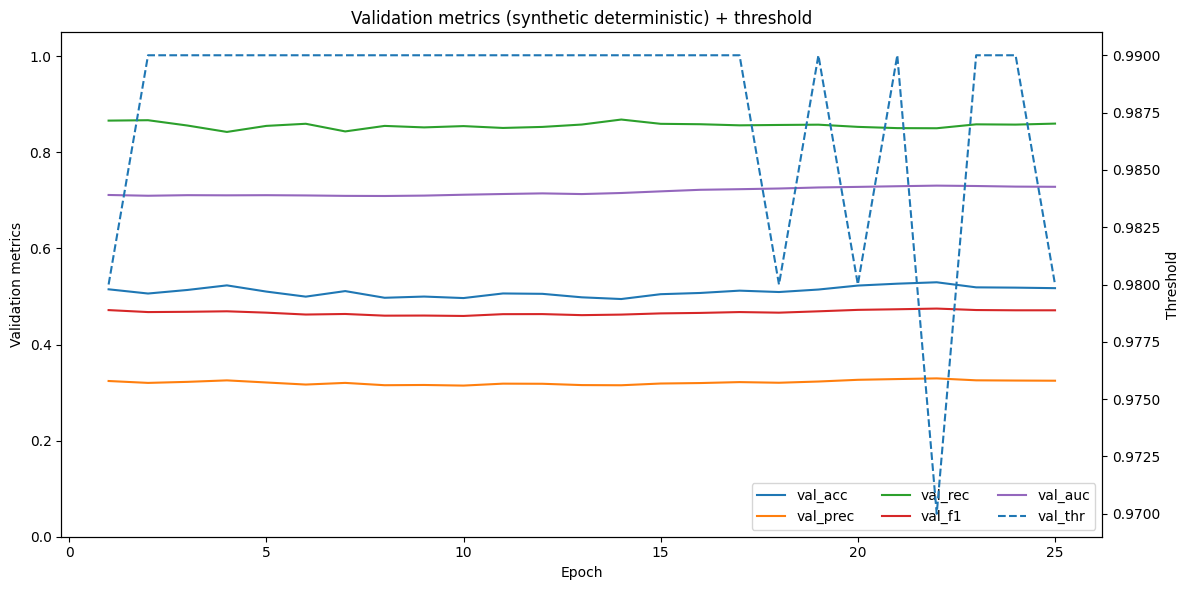

In [20]:
# -------------------------
# Plot metrics (one chart)
# -------------------------
import matplotlib.pyplot as plt

def ema(x, a=0.25):
    out, m = [], None
    for v in x:
        m = v if m is None else a*v + (1-a)*m
        out.append(m)
    return np.array(out)

epochs = np.arange(1, len(metrics_hist["val_auc"])+1)
plt.figure(figsize=(12,6))
ax = plt.gca()
for k in ["val_acc","val_prec","val_rec","val_f1","val_auc"]:
    ax.plot(epochs, ema(metrics_hist[k], 0.25), label=k)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation metrics")

ax2 = ax.twinx()
ax2.plot(epochs, metrics_hist["val_thr"], "--", label="val_thr")
ax2.set_ylabel("Threshold")

lines, labels = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines + l2, labels + lab2, loc="lower right", ncol=3)
plt.title("Validation metrics (synthetic deterministic) + threshold")
plt.tight_layout()
plt.show()